# Decision Tree, Random Forest, XG Boost #

Der Decision Tree soll aussagen, welche Faktoren die Bewertungen von Airbnb-Unterkünften in Berlin beeinflussen/vorhersagen?

Die Zielvariable ist review_score-rating. Bei welchen Features/Merkmalen fällt diese besonders positiv aus? Welche Eigenschaften einer Airbnb-Unterkunft führen zu hohen Bewertungen?

## 1. Kodierungen/Bereinigung der Tabelle ##

1. Lösche alle unnötigen Spalten und Freitextspalten
2. Kodiere room_type in binäres System (z.B. Private Room ja = 1, nein = 0)


In [3]:
import pandas as pd

In [3]:
#1.
import pandas as pd

df = pd.read_csv("listings_clean.csv")

drop_columns = [
    "id",
    "listing_url",
    "review_scores_accuracy",
    "review_scores_cleanliness",
    "review_scores_checkin",
    "review_scores_communication",
    "review_scores_location",
    "review_scores_value",
    "reviews_per_month",
    "number_of_reviews"
]

df_cleaned = df.drop(columns=drop_columns)

df_cleaned.to_csv("listings_cleaned4Decision.csv", index=False)

print("Neue CSV wurde erstellt: listings_cleaned4Decision.csv")

Neue CSV wurde erstellt: listings_cleaned4Decision.csv


für 2. wird instant_bookable binär in 1 = true und 0 = false kodiert. 

für neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type wird die Methode One-Hot-Encoding verwendet, womit kategoriale Variablen in numerische Vektoren umzuwandeln. Dabei wird für jede Ausprägung eine eigene Spalte erstellt. Ein Wert von \(1\) signalisiert das Vorhandensein dieser Kategorie, während alle anderen Spalten den Wert \(0\) erhalten.

Pro Kategorie wird dann eine neue Variable mit vorheriger Spaltenbezeichnung_Kategorie gebildet.

In [7]:
#2. 
# CSV laden
df = pd.read_csv("listings_cleaned4Decision.csv")

# Binary Encoding
df["instant_bookable"] = df["instant_bookable"].map({
    "t": 1,
    "f": 0
})


# One-Hot-Encoding
categorical_columns = [
    "neighbourhood_cleansed",
    "neighbourhood_group_cleansed",
    "property_type",
    "room_type"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    dtype=int
)


# Neue CSV speichern
df.to_csv(
    "listings_cleaned4Decision_encoded.csv",
    index=False
)

print("Neue Datei erstellt.")

Neue Datei erstellt.


## 2. Decision Tree ##

1. wir bereiten die Daten vor

In [7]:
df = pd.read_csv("listings_cleaned4Decision_encoded.csv")

# Zielvariable
y = df["review_scores_rating"]

# Features
X = df.drop("review_scores_rating", axis=1)



2. Testdaten von 20 % werden abgetrennt

In [8]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

3. Teilen die verbleibenden 80 % in 60-20 auf für das Training und die Validierung. Dann nutzen wir 25 % der Trainingsdaten zum Testen

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

4. Nun trainieren wir den Baum - wir wollen einen DecisionTreeRegressor, weil...

In [11]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_le

5. Validierung

In [12]:
from sklearn.metrics import r2_score

val_predictions = tree.predict(X_val)

val_r2 = r2_score(y_val, val_predictions)

print("Validation R²:", val_r2)

Validation R²: 0.14632979365603627


R^2 ist sehr gering

6. Auf Testdaten prüfen

In [13]:
test_predictions = tree.predict(X_test)

test_r2 = r2_score(y_test, test_predictions)

print("Test R²:", test_r2)

Test R²: 0.11903404812973517


7. Baum visualisieren

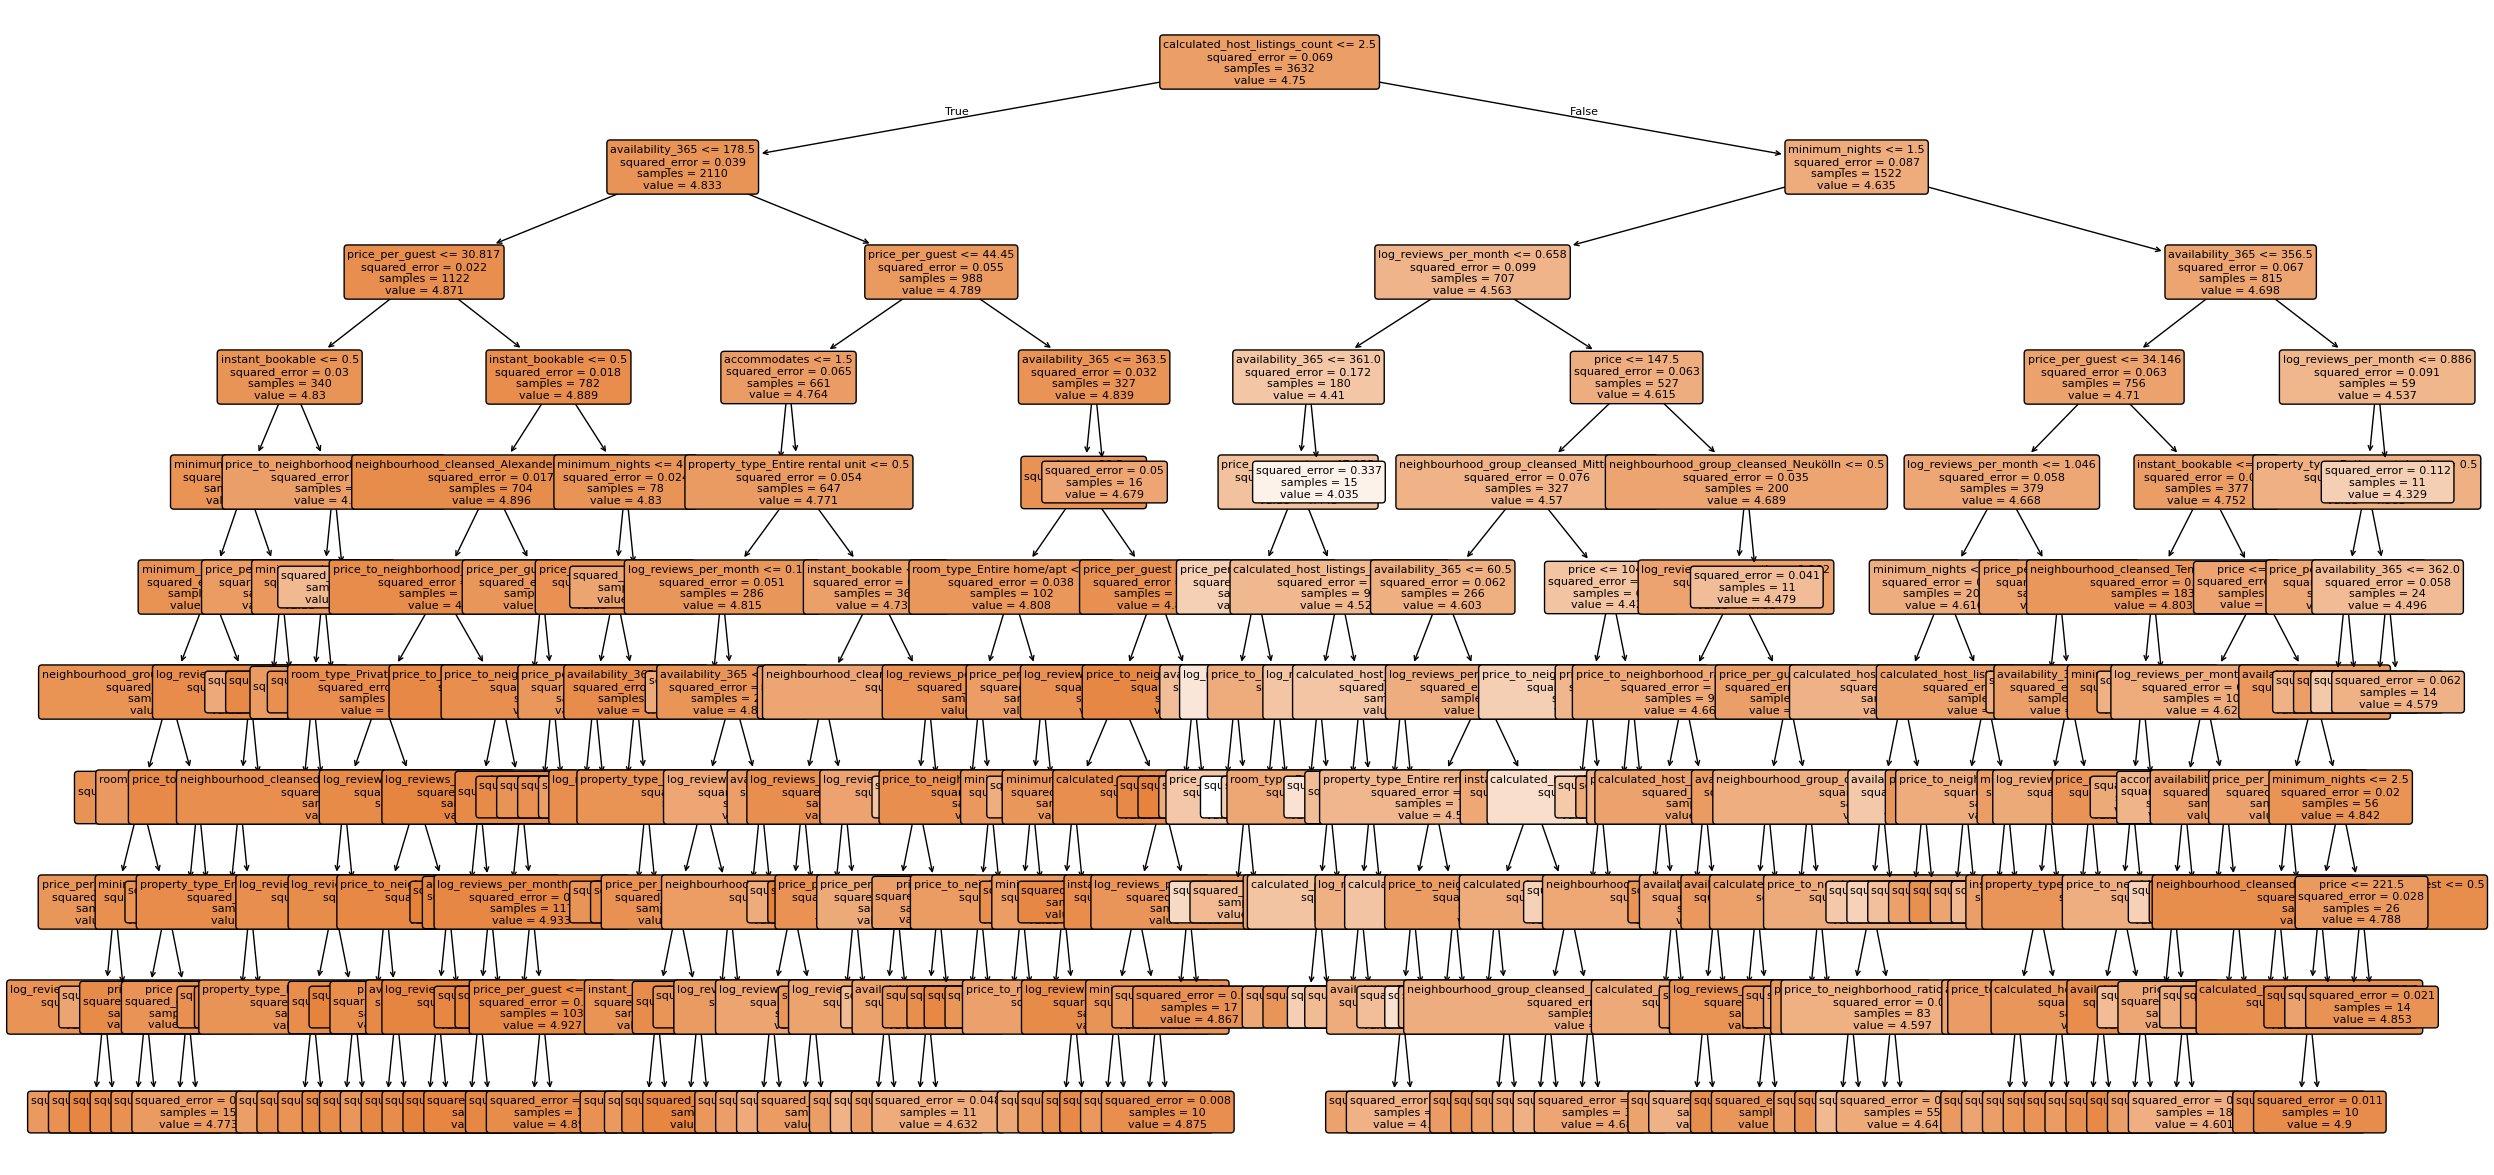

In [14]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30,15))

plot_tree(
    tree,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

8. wichtige Features bestimmen

In [15]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                                               Feature  Importance
5                       calculated_host_listings_count    0.353073
8                                log_reviews_per_month    0.128592
3                                     availability_365    0.107177
6                                      price_per_guest    0.101034
2                                       minimum_nights    0.087870
1                                                price    0.057209
7                          price_to_neighborhood_ratio    0.040488
4                                     instant_bookable    0.027650
0                                         accommodates    0.020427
171                   property_type_Entire rental unit    0.017808
148                 neighbourhood_group_cleansed_Mitte    0.016593
155    neighbourhood_group_cleansed_Treptow - Köpenick    0.009091
42     neighbourhood_cleansed_Frankfurter Allee Süd FK    0.006292
215                          room_type_Entire home/apt    0.00

9 Baum als Text ausgeben

In [16]:
from sklearn.tree import export_text

tree_rules = export_text(
    tree,
    feature_names=list(X.columns)
)

print(tree_rules)

|--- calculated_host_listings_count <= 2.50
|   |--- availability_365 <= 178.50
|   |   |--- price_per_guest <= 30.82
|   |   |   |--- instant_bookable <= 0.50
|   |   |   |   |--- minimum_nights <= 91.00
|   |   |   |   |   |--- minimum_nights <= 4.50
|   |   |   |   |   |   |--- neighbourhood_group_cleansed_Mitte <= 0.50
|   |   |   |   |   |   |   |--- price <= 58.50
|   |   |   |   |   |   |   |   |--- price_per_guest <= 27.75
|   |   |   |   |   |   |   |   |   |--- log_reviews_per_month <= 0.67
|   |   |   |   |   |   |   |   |   |   |--- value: [4.78]
|   |   |   |   |   |   |   |   |   |--- log_reviews_per_month >  0.67
|   |   |   |   |   |   |   |   |   |   |--- value: [4.86]
|   |   |   |   |   |   |   |   |--- price_per_guest >  27.75
|   |   |   |   |   |   |   |   |   |--- value: [4.69]
|   |   |   |   |   |   |   |--- price >  58.50
|   |   |   |   |   |   |   |   |--- minimum_nights <= 2.50
|   |   |   |   |   |   |   |   |   |--- price <= 70.50
|   |   |   |   |   |   

probieren von weiteren Bäumen

In [24]:
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=16,
    random_state=42
)

tree.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",16
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

In [25]:
from sklearn.metrics import r2_score

val_predictions = tree.predict(X_val)

val_r2 = r2_score(y_val, val_predictions)

print("Validation R²:", val_r2)

Validation R²: 0.19686908391874203


In [26]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                                             Feature  Importance
5                     calculated_host_listings_count    0.553952
2                                     minimum_nights    0.119595
3                                   availability_365    0.106583
8                              log_reviews_per_month    0.090765
6                                    price_per_guest    0.089315
1                                              price    0.028076
4                                   instant_bookable    0.011714
0                                       accommodates    0.000000
7                        price_to_neighborhood_ratio    0.000000
9                   neighbourhood_cleansed_Adlershof    0.000000
10               neighbourhood_cleansed_Albrechtstr.    0.000000
11             neighbourhood_cleansed_Alexanderplatz    0.000000
12            neighbourhood_cleansed_Allende-Viertel    0.000000
13               neighbourhood_cleansed_Alt  Treptow    0.000000
14  neighbourhood_cleanse

In [27]:
test_predictions = tree.predict(X_test)

test_r2 = r2_score(y_test, test_predictions)

print("Test R²:", test_r2)

Test R²: 0.1689889815843273


In [28]:
from sklearn.tree import export_text

tree_rules = export_text(
    tree,
    feature_names=list(X.columns)
)

print(tree_rules)

|--- calculated_host_listings_count <= 2.50
|   |--- availability_365 <= 178.50
|   |   |--- price_per_guest <= 30.82
|   |   |   |--- instant_bookable <= 0.50
|   |   |   |   |--- value: [4.84]
|   |   |   |--- instant_bookable >  0.50
|   |   |   |   |--- value: [4.74]
|   |   |--- price_per_guest >  30.82
|   |   |   |--- instant_bookable <= 0.50
|   |   |   |   |--- value: [4.90]
|   |   |   |--- instant_bookable >  0.50
|   |   |   |   |--- value: [4.83]
|   |--- availability_365 >  178.50
|   |   |--- price_per_guest <= 44.45
|   |   |   |--- availability_365 <= 327.50
|   |   |   |   |--- value: [4.79]
|   |   |   |--- availability_365 >  327.50
|   |   |   |   |--- value: [4.71]
|   |   |--- price_per_guest >  44.45
|   |   |   |--- availability_365 <= 363.50
|   |   |   |   |--- value: [4.85]
|   |   |   |--- availability_365 >  363.50
|   |   |   |   |--- value: [4.68]
|--- calculated_host_listings_count >  2.50
|   |--- minimum_nights <= 1.50
|   |   |--- log_reviews_per_mon

## 3. Random Forest ##


In [ ]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=100, #Anzahl Bäume
    max_depth=10, #Wie tief jeder einzelne Baum werden darf.
    min_samples_leaf=10, #Verhindert Overfitting
    random_state=42,
    n_jobs=-1 #Nutzt alle CPU-Kerne
)

In [31]:
#Trainieren
forest.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [32]:
#Vorhersage erzeugen
predictions = forest.predict(X_test)

In [33]:
#Güte bewerten
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R²:", r2)
print("MAE:", mae)

R²: 0.2766830104739396
MAE: 0.14739270126039147


In [34]:
# Wichtige Features analysieren
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

                                               Feature  Importance
5                       calculated_host_listings_count    0.323059
8                                log_reviews_per_month    0.133478
3                                     availability_365    0.131668
6                                      price_per_guest    0.103811
2                                       minimum_nights    0.081566
1                                                price    0.058474
7                          price_to_neighborhood_ratio    0.056638
4                                     instant_bookable    0.032736
171                   property_type_Entire rental unit    0.015714
0                                         accommodates    0.013908
148                 neighbourhood_group_cleansed_Mitte    0.011735
155    neighbourhood_group_cleansed_Treptow - Köpenick    0.005607
145  neighbourhood_group_cleansed_Friedrichshain-Kr...    0.004886
217                             room_type_Private room    0.00

## 4. XG Boost ##

In [36]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("R²:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))

R²: 0.26897241425554175
MAE: 0.1465340182290995


In [39]:
#für 60-20-20 Split
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)

print("Test R²:", r2_score(y_test, xgb_pred))
print("Test MAE:", mean_absolute_error(y_test, xgb_pred))

Test R²: 0.288901910896471
Test MAE: 0.14335964869901627


In [38]:
#feature importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(20))

                                               Feature  Importance
5                       calculated_host_listings_count    0.048472
4                                     instant_bookable    0.040105
126        neighbourhood_cleansed_Tempelhofer Vorstadt    0.033844
61         neighbourhood_cleansed_Karl-Marx-Allee-Nord    0.030547
124               neighbourhood_cleansed_Teltower Damm    0.027527
94                        neighbourhood_cleansed_Ost 1    0.026281
31                       neighbourhood_cleansed_Buckow    0.025978
145  neighbourhood_group_cleansed_Friedrichshain-Kr...    0.023971
172            property_type_Entire serviced apartment    0.023700
42     neighbourhood_cleansed_Frankfurter Allee Süd FK    0.023042
204                        property_type_Room in hotel    0.021801
217                             room_type_Private room    0.021058
2                                       minimum_nights    0.018666
152               neighbourhood_group_cleansed_Spandau    0.01

## 5. Laufen lassen auf bestimmten Features ##

Bisher als wichtig herauskristallisierte Features - Kriterium > 0,01
Einzelner Baum
|Feature | Importance|
|--- |---|
|calculated_host_listings_count  |  0.353073|
|log_reviews_per_month   | 0.128592|
|availability_365 |   0.107177|
|price_per_guest  |  0.101034|
|minimum_nights   | 0.087870|
| price |   0.057209|
|price_to_neighborhood_ratio   | 0.040488|
|instant_bookable |   0.027650|
| accommodates    |0.020427|
|property_type_Entire rental unit    |0.017808|
| neighbourhood_group_cleansed_Mitte   | 0.016593|


Random Forest
|Feature | Importance|
|--- |---|
|calculated_host_listings_count |   0.323059|
|log_reviews_per_month  |  0.133478|
 |availability_365  |  0.131668|
  |price_per_guest  |  0.103811|
 |minimum_nights |   0.081566|
 |price   | 0.058474|
 |price_to_neighborhood_ratio   | 0.056638|
 |instant_bookable   | 0.032736|
|property_type_Entire rental unit   | 0.015714|
 |accommodates |   0.013908|
|neighbourhood_group_cleansed_Mitte  |  0.011735|

XG Boost
|Feature | Importance|
|--- |---|
|calculated_host_listings_count  |  0.048472|
 |instant_bookable  |  0.040105|
|neighbourhood_cleansed_Tempelhofer Vorstadt  |  0.033844|
 |neighbourhood_cleansed_Karl-Marx-Allee-Nord  |  0.030547|
|neighbourhood_cleansed_Teltower Damm  |  0.027527|
|neighbourhood_cleansed_Ost 1  |  0.026281|
|neighbourhood_cleansed_Buckow |   0.025978|
|neighbourhood_group_cleansed_Friedrichshain-Kr...   | 0.023971|
|property_type_Entire serviced apartment   | 0.023700|
|neighbourhood_cleansed_Frankfurter Allee Süd FK  |  0.023042|
 |property_type_Room in hotel   | 0.021801|
 |room_type_Private room  |  0.021058|
 |minimum_nights  |  0.018666|
 |neighbourhood_group_cleansed_Spandau   | 0.017651|
|neighbourhood_cleansed_Otto-Suhr-Allee  |  0.017416|
|property_type_Private room in bed and breakfast |   0.014566|
 |neighbourhood_cleansed_Neu Lichtenberg  |  0.014371|
|neighbourhood_group_cleansed_Mitte   | 0.014353|
 |neighbourhood_cleansed_Moabit West   | 0.014324|
|log_reviews_per_month   | 0.014142|


Idee nächste Schritte. 1. Einmal nur mit Nachbarschaft_cleansed Methoden durchlaufen lassen.
2. Alle Methoden mit nur Nachbarschaft_Group durchlaufen lassen
3. Einmal mit allen außer den Nachbarschaften durchlaufen lassen
4. Einmal mit den selektierten wichtigsten Features durchlaufen lassen

In [40]:
#Dafür Datenneusortierung auf Tabellenblätter
import pandas as pd

# Datei laden
df = pd.read_csv("listings_cleaned4Decision_encoded.csv")

target = "review_scores_rating"

# One-Hot-Spalten erkennen
neighbourhood_cleansed_cols = [
    col for col in df.columns 
    if col.startswith("neighbourhood_cleansed_")
]

neighbourhood_group_cols = [
    col for col in df.columns 
    if col.startswith("neighbourhood_group_cleansed_")
]

# Alle Nachbarschaftsspalten
all_neighbourhood_cols = neighbourhood_cleansed_cols + neighbourhood_group_cols

# 1. Nur neighbourhood_cleansed
df_neighbourhood_cleansed = df[neighbourhood_cleansed_cols + [target]]

# 2. Nur neighbourhood_group_cleansed
df_neighbourhood_group = df[neighbourhood_group_cols + [target]]

# 3. Alle außer Nachbarschaften
df_without_neighbourhoods = df.drop(columns=all_neighbourhood_cols)

# 4. Selektierte wichtigste Features
selected_features = [
    "price",
    "availability_365",
    "number_of_reviews",
    "instant_bookable",
    "calculated_host_listings_count",
    "price_per_guest",
    "price_to_neighborhood_ratio",
    "log_reviews_per_month"
]

selected_features = [
    col for col in selected_features 
    if col in df.columns
]

df_selected = df[selected_features + [target]]

# 5. Alle Features
df_all = df.copy()

# Neue Excel-Datei mit mehreren Tabellenblättern erstellen
with pd.ExcelWriter("airbnb_feature_sets.xlsx", engine="openpyxl") as writer:
    df_neighbourhood_cleansed.to_excel(
        writer, 
        sheet_name="Nur_Neighbourhood", 
        index=False
    )

    df_neighbourhood_group.to_excel(
        writer, 
        sheet_name="Nur_Group", 
        index=False
    )

    df_without_neighbourhoods.to_excel(
        writer, 
        sheet_name="Ohne_Neighbourhoods", 
        index=False
    )

    df_selected.to_excel(
        writer, 
        sheet_name="Selected_Features", 
        index=False
    )

    df_all.to_excel(
        writer, 
        sheet_name="Alle_Features", 
        index=False
    )

print("Datei wurde erstellt: listings_clean_feature_sets.xlsx")

Datei wurde erstellt: listings_clean_feature_sets.xlsx


In [48]:
#Sheet auswählen
sheet_name = "Ohne_Neighbourhoods"

#Daten vorbereiten
df = pd.read_excel("airbnb_feature_sets.xlsx", sheet_name=sheet_name)

# Zielvariable
y = df["review_scores_rating"]

# Features
X = df.drop("review_scores_rating", axis=1)

#Cross-Validation
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42
)

#Trainieren Baum
from sklearn.tree import DecisionTreeRegressor

tree = DecisionTreeRegressor(
    max_depth=10,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

#Validieren
from sklearn.metrics import r2_score

val_predictions = tree.predict(X_val)

val_r2 = r2_score(y_val, val_predictions)

print("Validation R²:", val_r2)

#testen
test_predictions = tree.predict(X_test)

test_r2 = r2_score(y_test, test_predictions)

print("Test R²:", test_r2)

Validation R²: 0.16414547262136814
Test R²: 0.12973369283095493


Ergebnisse: 

Nur_Neighbourhood: R^2 -0,01; Test R^2: 0,00

Nur_Group: Validation R^2 = -0,00; Test R^2 = -0,00

Ohne_Neighbourhoods: Validation: R^2 = 0,16; Test R^2 = 0,13

Selected_Features: Validitation R^2 = 0,11; Test R^2 = 0,08



Entscheidung: Erstmal mit Ohne_Neighbourhoods rechnen, da die Nachbarschaften nichts von der Varianz der Gesamtbewertung erklärt. Die Stadtteile alleine liefern praktisch keine Vorhersagekraft. Bei Selected_Features wurden zu viele relevante Informationen gelöscht, damit ist der Verlust der Erklärbarkeit zu erklären.

### Random Forest auf Ohne_neighbourhoods ###

In [49]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor(
    n_estimators=100, #Anzahl Bäume
    max_depth=10, #Wie tief jeder einzelne Baum werden darf.
    min_samples_leaf=10, #Verhindert Overfitting
    random_state=42,
    n_jobs=-1 #Nutzt alle CPU-Kerne
)

#Trainieren
forest.fit(X_train, y_train)

#Vorhersage erzeugen
predictions = forest.predict(X_test)

#Güte bewerten
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(y_test, predictions)
mae = mean_absolute_error(y_test, predictions)

print("R²:", r2)
print("MAE:", mae)

# Wichtige Features analysieren
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))

R²: 0.27782194979205166
MAE: 0.14768406161794093
                                      Feature  Importance
5              calculated_host_listings_count    0.325195
8                       log_reviews_per_month    0.140756
3                            availability_365    0.138751
6                             price_per_guest    0.108785
2                              minimum_nights    0.084467
1                                       price    0.062617
7                 price_to_neighborhood_ratio    0.060977
4                            instant_bookable    0.034025
0                                accommodates    0.015124
24           property_type_Entire rental unit    0.014998
68                  room_type_Entire home/apt    0.003986
70                     room_type_Private room    0.003938
57                property_type_Room in hotel    0.002165
49  property_type_Private room in rental unit    0.001511
25    property_type_Entire serviced apartment    0.001032
44         property_typ

Interpretation: Die vorhergesagte Gesamtbewertung ist im Durchschnitt um circa 0,15 abweichend von der gegebenen Gesamtbewertung.

calculated_host_listings_count ist der wichtigste Faktor: Die Professionalität bzw. Größe des Hosts beeinflusst Bewertungen stark.

log-reviews_per_month erklärt 0,14. (average number of reviews a property receives monthly) - Erklärung?/Interpretation?

Room Type und Property Type sind fast irrelevant - Unterkunftstypen erklären Bewertungen kaum - überraschend

### XG Boost ###

In [50]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("R²:", r2_score(y_test, xgb_pred))
print("MAE:", mean_absolute_error(y_test, xgb_pred))

#für 60-20-20 Split
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=10,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_pred = xgb_model.predict(X_test)

print("Test R²:", r2_score(y_test, xgb_pred))
print("Test MAE:", mean_absolute_error(y_test, xgb_pred))

#feature importance
import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance.head(20))

R²: 0.26635632584648516
MAE: 0.14713966764958808
Test R²: 0.2871036974391761
Test MAE: 0.14788224628205937
                                             Feature  Importance
71                             room_type_Shared room    0.164559
57                       property_type_Room in hotel    0.066616
5                     calculated_host_listings_count    0.064320
63                property_type_Shared room in hotel    0.040214
59    property_type_Shared room in bed and breakfast    0.038276
50  property_type_Private room in serviced apartment    0.031122
33   property_type_Private room in bed and breakfast    0.030599
32                        property_type_Private room    0.027585
45              property_type_Private room in hostel    0.027275
55              property_type_Room in boutique hotel    0.027087
4                                   instant_bookable    0.026810
24                  property_type_Entire rental unit    0.023741
54                  property_type_Room in aparth